# 1- Importing and matching Data

- Get Parent directory from any location
- Import GEM xml file with original information
- Import firtered Compound Graph

In [3]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from etc.parse_ids import XMLParser

# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
data_folder = project_root / "data" / "resources"
Pilot = data_folder / "PilotStudy_All"

# Get graph prevouly fitered
graph_gml = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"

### Consortium sumarized data from different samples
- First we define a method to match the chebis with the HUMAN1
- Then upload data and apply changes

In [4]:
# Auxiliar function to extract the chebi number from a string like "CHEBI:12345"
def extract_single_chebi(value):
    """Extract CHEBI number from a single CHEBI string"""
    if pd.isna(value):
        return None
    match = re.search(r"CHEBI:(\d+)", str(value))
    if match:
        return int(match.group(1))
    return None

In [5]:
# Load the data file as a pandas DataFrame
data_file = pd.read_excel(Pilot / "Daniel_Suplementary_info.xlsx", sheet_name="Sheet1")

# Filter to only include rows where ID_level is 1
data_file = data_file[data_file.ID_level==1]

# Add new column with extracted CHEBI numbers
data_file['CHEBI_number'] = data_file.CHEBI_ID_Step2.apply(extract_single_chebi)

### From HUMAN1 GEM xml file 
- Create a dataframe
- Create colum to match chebis ids and link them with human1 ids

In [6]:
parser = XMLParser(human1_xml)
df = parser.extract_data()
df_human1 = parser.to_identifier_df()
df_human1['Consortium'] = None

### Matching and filling column

In [7]:
# Convert df_human1 CHEBI to integers for matching
df_human1['chebi_int'] = pd.to_numeric(df_human1['chebi'], errors='coerce').astype('Int64')
# Get set of CHEBIs from data_file
data_file_chebis = set(data_file['CHEBI_number'].dropna().values)

# Fill Consortium column with boolean: True if CHEBI matches, False otherwise
df_human1['Consortium'] = df_human1['chebi_int'].isin(data_file_chebis)

print(f"Consortium column filled with boolean values")
print(f"True matches: {df_human1['Consortium'].sum()}")
print(f"False (no match): {(~df_human1['Consortium']).sum()}")

Consortium column filled with boolean values
True matches: 356
False (no match): 8100


In [8]:
# Find CHEBIs in data_file that are NOT in df_human1
df_human1_chebis = set(df_human1['chebi_int'].dropna().values)
data_file_chebis_set = set(data_file['CHEBI_number'].dropna().values)

# CHEBIs not found in df_human1
unmatched_chebis = data_file_chebis_set - df_human1_chebis

print(f"Total CHEBIs in data_file: {len(data_file_chebis_set)}")
print(f"CHEBIs found in df_human1: {len(data_file_chebis_set - unmatched_chebis)}")
print(f"CHEBIs NOT found in df_human1: {len(unmatched_chebis)}")
print(f"\nUnmatched CHEBIs: {sorted(unmatched_chebis)}")

Total CHEBIs in data_file: 228
CHEBIs found in df_human1: 105
CHEBIs NOT found in df_human1: 123

Unmatched CHEBIs: [np.int64(4139), np.int64(4828), np.int64(9008), np.int64(11901), np.int64(14314), np.int64(15620), np.int64(15761), np.int64(16020), np.int64(16113), np.int64(16119), np.int64(16231), np.int64(16312), np.int64(16347), np.int64(16373), np.int64(16831), np.int64(17012), np.int64(17016), np.int64(17072), np.int64(17234), np.int64(17597), np.int64(17687), np.int64(17780), np.int64(18123), np.int64(19030), np.int64(19062), np.int64(19065), np.int64(19660), np.int64(21264), np.int64(21553), np.int64(21563), np.int64(21756), np.int64(21949), np.int64(25858), np.int64(27410), np.int64(27596), np.int64(27732), np.int64(27747), np.int64(27838), np.int64(28123), np.int64(28177), np.int64(28238), np.int64(28393), np.int64(28664), np.int64(28717), np.int64(28775), np.int64(28821), np.int64(28871), np.int64(28946), np.int64(30753), np.int64(30776), np.int64(30845), np.int64(35280), np

note: 123 metbolites from the data couldn't be match on HUMAN1, note some are lipis and most of them considered sidecompounds that will not be taken into account in the model. Also we only included level 1 annotated metabolites

### Mask to separate annotations 

In [9]:
capitainer = data_file[data_file.Capitainer == "Yes"]
mitra = data_file[data_file.Mitra == "Yes"]
whatman = data_file[data_file.Whatman == "Yes"]
blood = data_file[data_file.Blood == "Yes"]
plasma = data_file[data_file.Plasma == "Yes"]

k_capitainer = capitainer.CHEBI_ID_Step2.unique().shape[0]
k_mitra = mitra.CHEBI_ID_Step2.unique().shape[0]
k_whatman = whatman.CHEBI_ID_Step2.unique().shape[0]
k_blood = blood.CHEBI_ID_Step2.unique().shape[0]
k_plasma = plasma.CHEBI_ID_Step2.unique().shape[0]

print("Capitainer annotations:", k_capitainer)
print("Mitra annotations:", k_mitra)
print("Whatman annotations:", k_whatman)
print("Blood annotations:", k_blood)
print("Plasma annotations:", k_plasma)

Capitainer annotations: 212
Mitra annotations: 209
Whatman annotations: 209
Blood annotations: 201
Plasma annotations: 199


# 2- Model application
From here we will be using the graph  directly and showing results on the human1 graph

In [11]:
import networkx as nx
from etc.hamiltonian import Hamiltonian
from etc.coverage import Coverage

### Define H object and parameters of G

In [ ]:
graph = nx.read_gml(graph_gml)
H = Hamiltonian(graph)
mu = H.mu_density_aware(graph)
gamma = H.gamma_balancer(mu=mu)
n = graph.number_of_nodes()
C = Coverage(H)

In [19]:
energy_values_capitainer, min_energy_capitainer, max_energy_capitainer = C.sample_energy(
    n=n,k=k_capitainer, mu=mu, gamma=gamma,n_samples=1000)

In [20]:
energy_values_mitra, min_energy_mitra, max_energy_mitra = C.sample_energy(
    n=n,k=k_mitra, mu=mu, gamma=gamma,n_samples=1000)

In [21]:
energy_values_whatman, min_energy_whatman, max_energy_whatman = C.sample_energy(
    n=n,k=k_whatman, mu=mu, gamma=gamma,n_samples=1000)

In [22]:
eneergy_values_blood, min_energy_blood, max_energy_blood = C.sample_energy(
    n=n,k=k_blood, mu=mu, gamma=gamma,n_samples=1000)

In [23]:
enerrgy_values_plasma, min_energy_plasma, max_energy_plasma = C.sample_energy(
    n=n,k=k_plasma, mu=mu, gamma=gamma,n_samples=1000)

# 3- Visualization

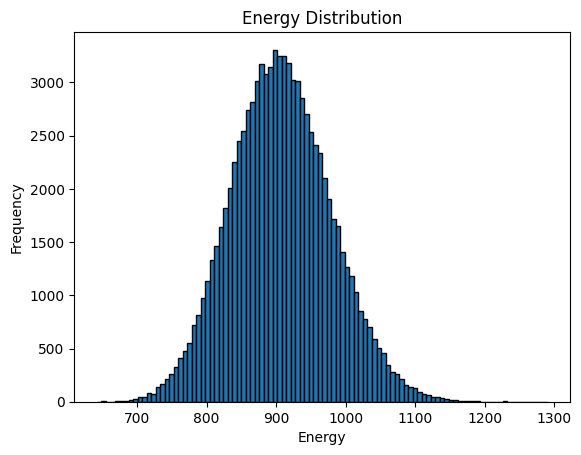

In [19]:
import matplotlib.pyplot as plt

plt.hist(energy_values, bins=100, edgecolor='black')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distribution')
plt.show()